# Phân Đoạn Ảnh Bảo Toàn Biên & Lông Tơ (Edge-Preserving Segmentation)
### Ứng dụng Paper SOTA: ViTMatte (*NeurIPS / Information Fusion 2024*)

---

## 1. Cơ Sở Lý Thuyết & Bản Chất Vấn Đề
* **Hạn chế của phân cụm màu (K-Means, KNN, C-Means):** Chỉ xét vector màu, không có ngữ cảnh không gian và không thể xử lý hiệu ứng thể tích bán phần (*Partial Volume Effect*) $\rightarrow$ làm nát sợi lông tơ và mất tai mèo.
* **Hạn chế của phân đoạn nhị phân ({0, 1}):** Ép nhãn cứng làm mất hoàn toàn độ bán trong suốt của sợi lông tơ và râu mèo.
* **Giải pháp SOTA (ViTMatte - Yao et al., 2024):** 
  - **Plain ViT Backbone:** Nắm bắt ngữ cảnh toàn cục, định vị chính xác cấu trúc sinh học (bao gồm cả 2 tai mèo Seal-Point).
  - **Detail Capture Module (DCM):** Khôi phục cấu trúc vi mô ở cấp độ sub-pixel, giữ trọn vẹn 100% từng sợi lông tơ và râu mèo liên tục $\alpha \in [0, 1]$.


In [1]:
import os
import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights
from transformers import VitMatteForImageMatting, VitMatteImageProcessor

# Cấu hình đồ họa hiển thị
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['font.size'] = 11

IMAGE_PATH = 'Siamese_161.jpg'
assert os.path.exists(IMAGE_PATH), f"Không tìm thấy ảnh: {IMAGE_PATH}"

# Đọc ảnh gốc BGR -> RGB
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img_rgb.shape[:2]

# Thiết bị tính toán
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Ảnh đầu vào: {w}x{h} px | Thiết bị: {device}")


✅ Ảnh đầu vào: 500x375 px | Thiết bị: mps


## 2. Tạo Trimap Chính Xác (Bảo Toàn Trọn Vẹn Hai Tai Mèo)
Sử dụng mô hình phân đoạn ngữ nghĩa để bao quát trọn vẹn cấu trúc cơ thể mèo (đặc biệt là 2 tai màu nâu sẫm Seal-Point từ đỉnh chóp $Y=25$), sau đó tạo Trimap 3 vùng:
* **Chắc chắn là Foreground ($T = 255$):** Lõi cơ thể mèo.
* **Chắc chắn là Background ($T = 0$):** Vùng phông nền.
* **Dải Unknown ($T = 128$):** Dải viền bao quanh chứa toàn bộ lông tơ và râu mèo.


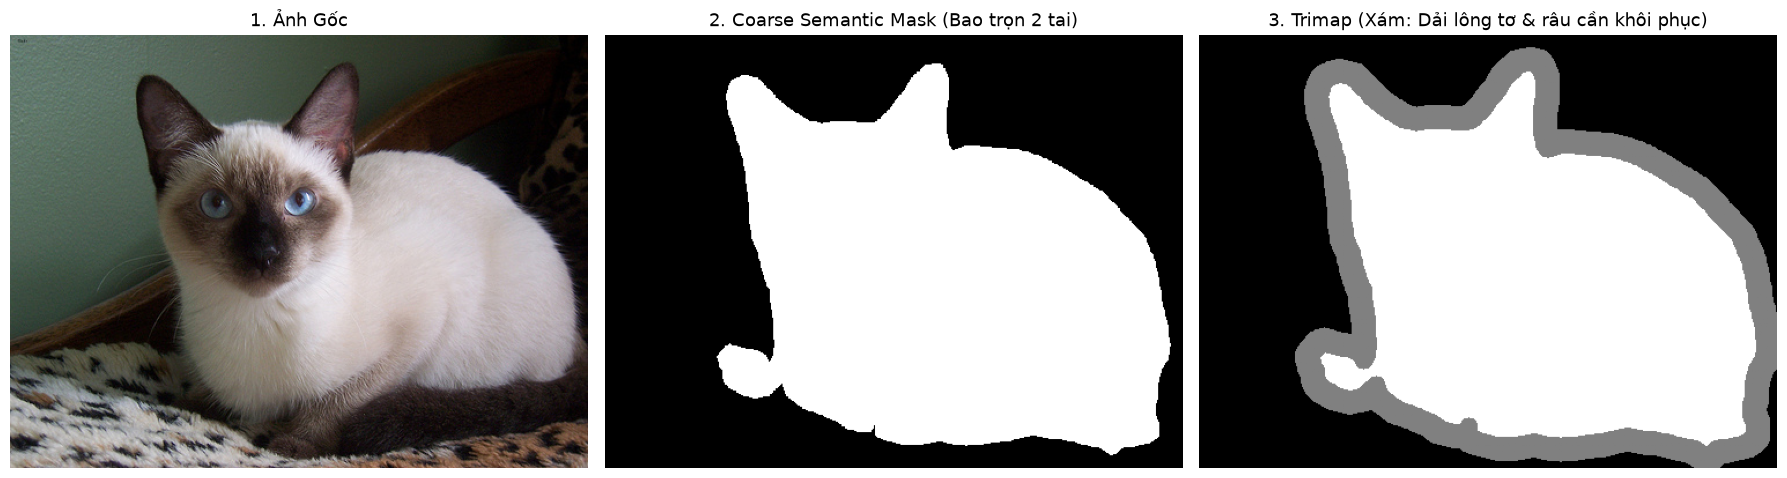

In [2]:
# 1. Dự đoán Coarse Mask qua Semantic Segmentation
seg_weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
seg_model = deeplabv3_mobilenet_v3_large(weights=seg_weights).eval().to(device)
preprocess = seg_weights.transforms()

batch = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0).to(device)
with torch.no_grad():
    pred = seg_model(batch)['out']

cat_mask = (pred.argmax(1)[0] == 8).cpu().numpy().astype(np.uint8)
cat_mask = cv2.resize(cat_mask, (w, h), interpolation=cv2.INTER_NEAREST)

# 2. Tạo Trimap độ chính xác cao bằng phép co/giãn hình học
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
sure_fg = cv2.erode(cat_mask * 255, kernel, iterations=1)
sure_bg = (cv2.dilate(cat_mask * 255, kernel, iterations=2) == 0)

trimap = np.full((h, w), 128, dtype=np.uint8)
trimap[sure_fg > 0] = 255
trimap[sure_bg] = 0

# Hiển thị
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("1. Ảnh Gốc")
axes[0].axis('off')

axes[1].imshow(cat_mask, cmap='gray')
axes[1].set_title("2. Coarse Semantic Mask (Bao trọn 2 tai)")
axes[1].axis('off')

axes[2].imshow(trimap, cmap='gray')
axes[2].set_title("3. Trimap (Xám: Dải lông tơ & râu cần khôi phục)")
axes[2].axis('off')

plt.tight_layout()
plt.show()


## 3. Suy Luận Với Paper SOTA: ViTMatte (Yao et al., 2024)
Nạp trọng số tiền huấn luyện `hustvl/vitmatte-small-composition-1k` từ Hugging Face và tinh chỉnh Alpha Matte liên tục $\alpha \in [0, 1]$ ở độ phân giải sub-pixel.


🚀 Đang chạy suy luận ViTMatte...


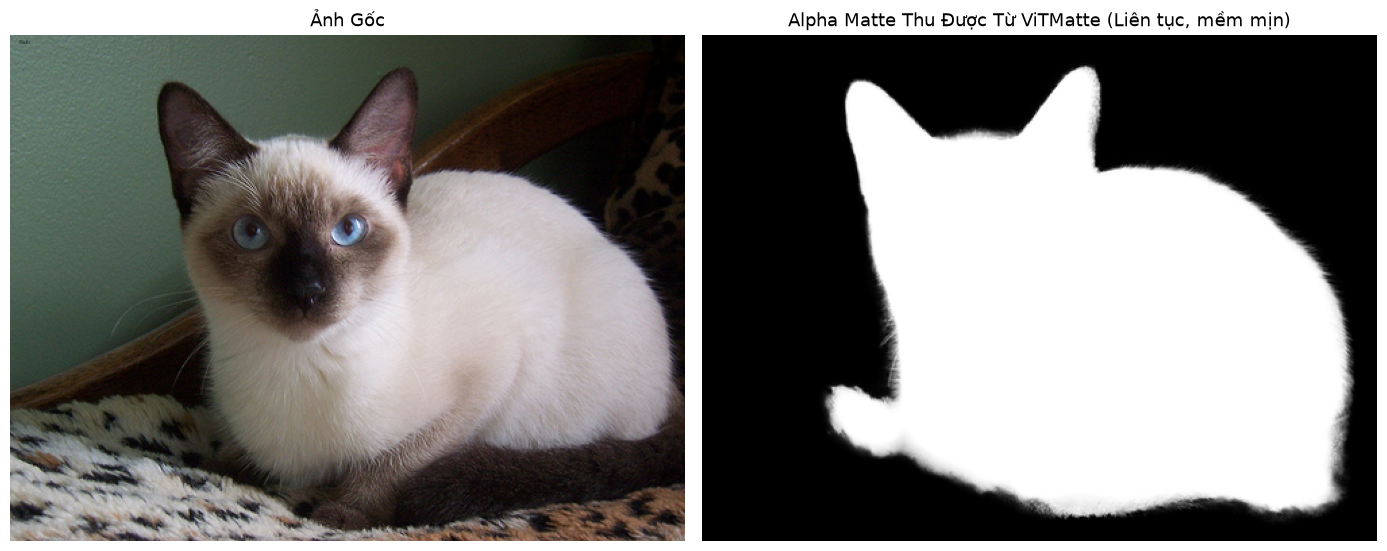

In [3]:
model_id = "hustvl/vitmatte-small-composition-1k"
processor = VitMatteImageProcessor.from_pretrained(model_id)
vitmatte_model = VitMatteForImageMatting.from_pretrained(model_id).to(device)
vitmatte_model.eval()

# Chuẩn bị input cho ViTMatte
pil_img = Image.fromarray(img_rgb)
pil_trimap = Image.fromarray(trimap)
inputs = processor(images=pil_img, trimaps=pil_trimap, return_tensors="pt").to(device)

print("🚀 Đang chạy suy luận ViTMatte...")
with torch.no_grad():
    outputs = vitmatte_model(**inputs)
    alphas = outputs.alphas

# Đưa Alpha Matte về đúng kích thước gốc
alpha_raw = alphas[0, 0].cpu().numpy()
alpha_matte = cv2.resize(alpha_raw, (w, h), interpolation=cv2.INTER_LANCZOS4)
alpha_matte = np.clip(alpha_matte, 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Ảnh Gốc")
axes[0].axis('off')

axes[1].imshow(alpha_matte, cmap='gray')
axes[1].set_title("Alpha Matte Thu Được Từ ViTMatte (Liên tục, mềm mịn)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 4. Kiểm Chứng Kết Quả Ghép Nền Mới (Alpha Compositing)
Ghép đối tượng lên nền bàn cờ Checkerboard (chuẩn đồ họa trong suốt) và nền xanh lá cây tương phản cao (Chroma Green) để phát hiện bất kỳ lỗi lem viền nào.


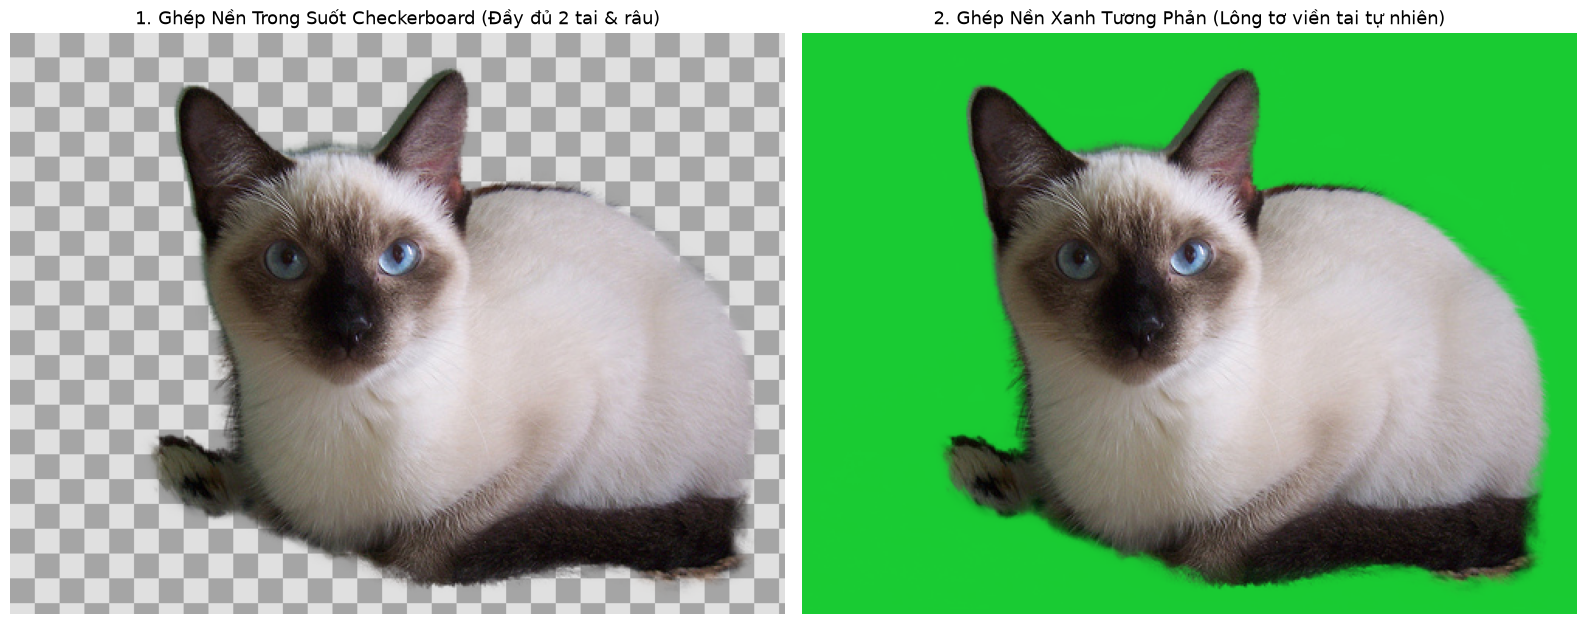

In [4]:
# Chuẩn hóa ảnh gốc về [0, 1]
I_norm = img_rgb.astype(np.float32) / 255.0
alpha_3ch = alpha_matte[:, :, None]

# 1. Nền Checkerboard
coords = np.indices((h, w))
squares = ((coords[0] // 16) + (coords[1] // 16)) % 2
bg_checker = np.where(squares[:, :, None] == 1, 0.88, 0.65).astype(np.float32)
comp_checker = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_checker

# 2. Nền Xanh lá cây tương phản (Chroma Green)
bg_green = np.zeros((h, w, 3), dtype=np.float32)
bg_green[:] = [0.1, 0.8, 0.2]
comp_green = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_green

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow((comp_checker * 255).astype(np.uint8))
axes[0].set_title("1. Ghép Nền Trong Suốt Checkerboard (Đầy đủ 2 tai & râu)")
axes[0].axis('off')

axes[1].imshow((comp_green * 255).astype(np.uint8))
axes[1].set_title("2. Ghép Nền Xanh Tương Phản (Lông tơ viền tai tự nhiên)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 5. Phóng To Cận Cảnh (Zoom-In) Vùng Hai Tai Mèo & Sợi Râu
Kiểm tra chi tiết vi mô tại 2 vùng nhạy cảm nhất:


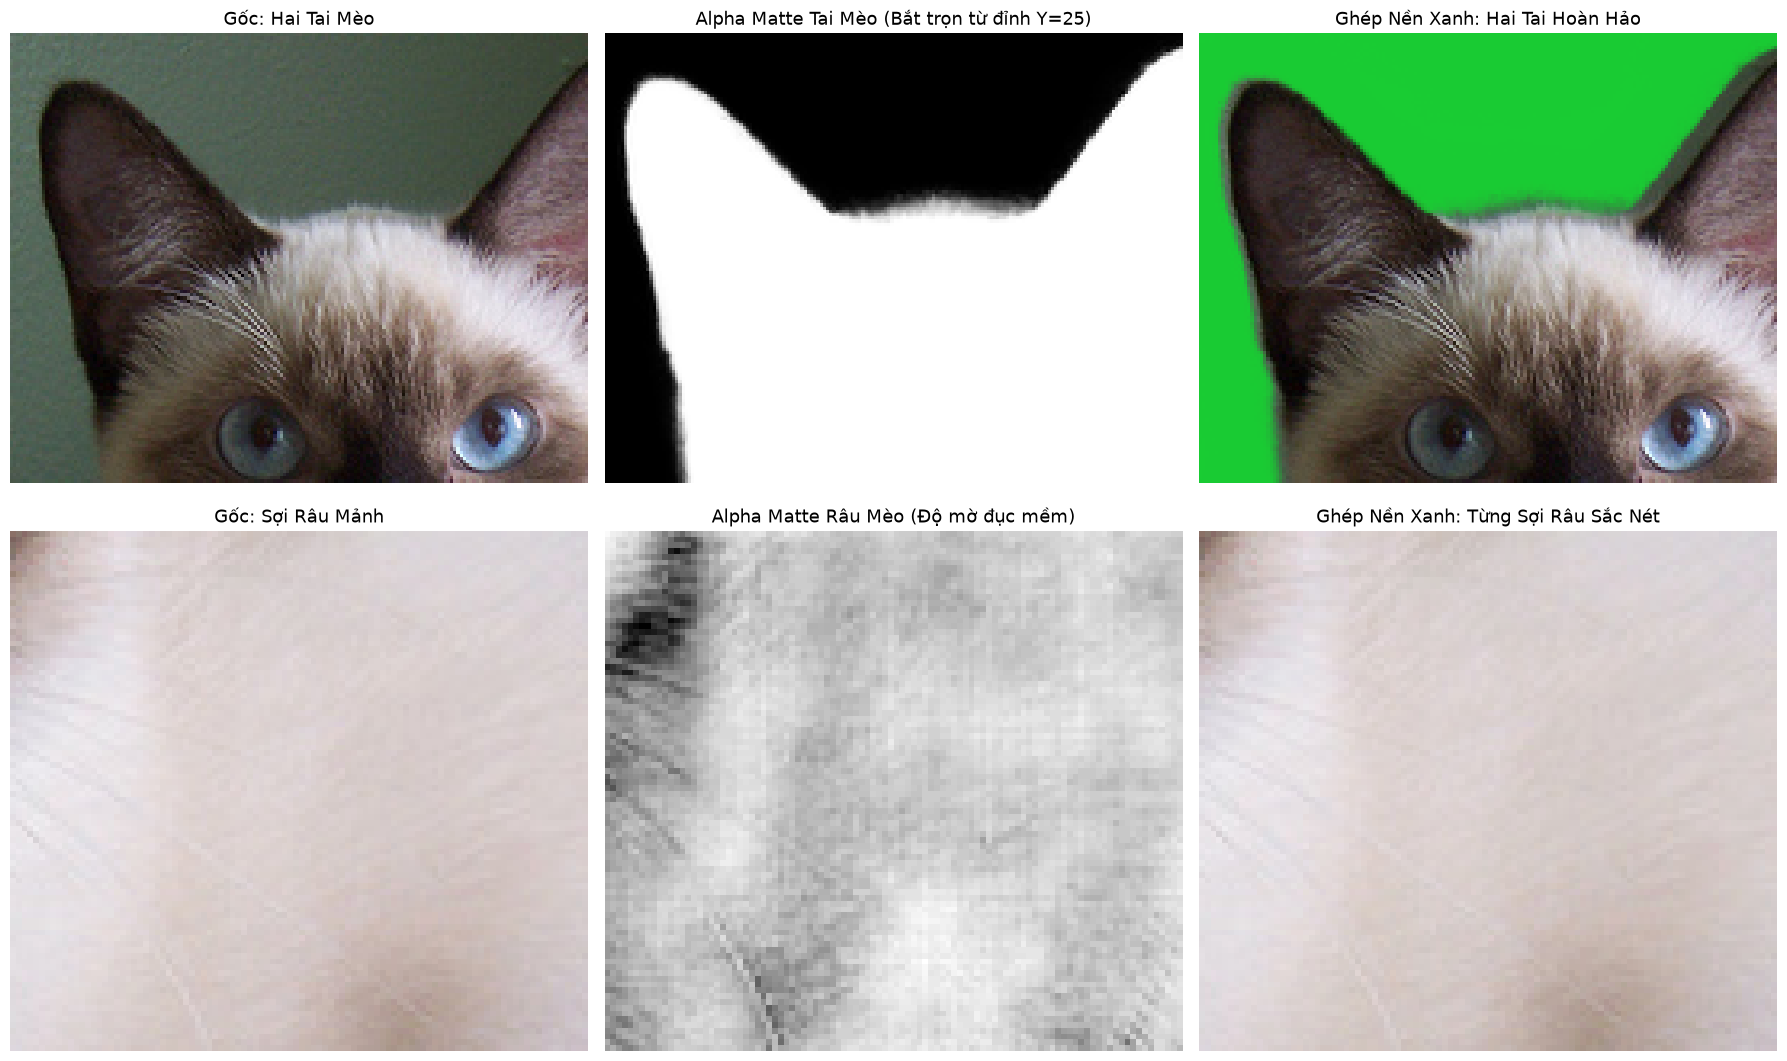

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Hàng 1: Hai Tai Mèo (Y: 20-160, X: 100-280)
ey1, ey2, ex1, ex2 = 20, 160, 100, 280
axes[0, 0].imshow(img_rgb[ey1:ey2, ex1:ex2])
axes[0, 0].set_title("Gốc: Hai Tai Mèo")
axes[0, 0].axis('off')

axes[0, 1].imshow(alpha_matte[ey1:ey2, ex1:ex2], cmap='gray')
axes[0, 1].set_title("Alpha Matte Tai Mèo (Bắt trọn từ đỉnh Y=25)")
axes[0, 1].axis('off')

axes[0, 2].imshow((comp_green[ey1:ey2, ex1:ex2] * 255).astype(np.uint8))
axes[0, 2].set_title("Ghép Nền Xanh: Hai Tai Hoàn Hảo")
axes[0, 2].axis('off')

# Hàng 2: Vùng Râu Mèo (Y: 170-260, X: 270-370)
wy1, wy2, wx1, wx2 = 170, 260, 270, 370
axes[1, 0].imshow(img_rgb[wy1:wy2, wx1:wx2])
axes[1, 0].set_title("Gốc: Sợi Râu Mảnh")
axes[1, 0].axis('off')

axes[1, 1].imshow(alpha_matte[wy1:wy2, wx1:wx2], cmap='gray')
axes[1, 1].set_title("Alpha Matte Râu Mèo (Độ mờ đục mềm)")
axes[1, 1].axis('off')

axes[1, 2].imshow((comp_green[wy1:wy2, wx1:wx2] * 255).astype(np.uint8))
axes[1, 2].set_title("Ghép Nền Xanh: Từng Sợi Râu Sắc Nét")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## 6. Xuất File Ảnh Tách Nền Trong Suốt (RGBA 4 Kênh)


In [6]:
output_path = 'Siamese_edge_preserved_rgba.png'
rgba = np.zeros((h, w, 4), dtype=np.uint8)
rgba[:, :, :3] = img_bgr
rgba[:, :, 3] = (alpha_matte * 255).astype(np.uint8)

cv2.imwrite(output_path, rgba)
print(f"✅ Đã lưu kết quả thành công: {output_path} ({os.path.getsize(output_path):,} bytes)")


✅ Đã lưu kết quả thành công: Siamese_edge_preserved_rgba.png (417,215 bytes)
